# Big Data Analytics - Airline Dataset
## PUSL3121 Coursework

## Step 1: Dataset Description and Pre-Processing

The original airline dataset was approximately 5GB with millions of records. A representative random sample of 1.8GB was selected to fit within Databricks upload limits while preserving the statistical distribution of the original data.

In [0]:
import gc
gc.collect()

from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql import SparkSession
from pyspark.sql.window import Window

spark = SparkSession.builder \
    .appName("AirlineAnalytics") \
    .getOrCreate()

df = spark.table("train")

In [0]:
df.show(5)

+-----------------+-------+--------+-------+----------+----------+--------------+----------------+---------+------------+---------+----------+--------+-------+----+--------+--------+---------+-----------------+-----+--------+------+-------------+-------+------+-------+-------------+------------+----+
|ActualElapsedTime|AirTime|ArrDelay|ArrTime|CRSArrTime|CRSDepTime|CRSElapsedTime|CancellationCode|Cancelled|CarrierDelay|DayOfWeek|DayofMonth|DepDelay|DepTime|Dest|Distance|Diverted|FlightNum|LateAircraftDelay|Month|NASDelay|Origin|SecurityDelay|TailNum|TaxiIn|TaxiOut|UniqueCarrier|WeatherDelay|Year|
+-----------------+-------+--------+-------+----------+----------+--------------+----------------+---------+------------+---------+----------+--------+-------+----+--------+--------+---------+-----------------+-----+--------+------+-------------+-------+------+-------+-------------+------------+----+
|            115.0|   97.0|    -6.0| 1029.0|      1035|       830|         125.0|            N

In [0]:
print("Number of rows:", df.count())
print("Number of columns:", len(df.columns))

Number of rows: 17922468
Number of columns: 29


In [0]:
df.printSchema()

root
 |-- ActualElapsedTime: double (nullable = true)
 |-- AirTime: double (nullable = true)
 |-- ArrDelay: double (nullable = true)
 |-- ArrTime: double (nullable = true)
 |-- CRSArrTime: long (nullable = true)
 |-- CRSDepTime: long (nullable = true)
 |-- CRSElapsedTime: double (nullable = true)
 |-- CancellationCode: string (nullable = true)
 |-- Cancelled: long (nullable = true)
 |-- CarrierDelay: double (nullable = true)
 |-- DayOfWeek: long (nullable = true)
 |-- DayofMonth: long (nullable = true)
 |-- DepDelay: double (nullable = true)
 |-- DepTime: double (nullable = true)
 |-- Dest: string (nullable = true)
 |-- Distance: double (nullable = true)
 |-- Diverted: long (nullable = true)
 |-- FlightNum: long (nullable = true)
 |-- LateAircraftDelay: double (nullable = true)
 |-- Month: long (nullable = true)
 |-- NASDelay: double (nullable = true)
 |-- Origin: string (nullable = true)
 |-- SecurityDelay: double (nullable = true)
 |-- TailNum: string (nullable = true)
 |-- TaxiIn: d

In [0]:
df.describe().show()

+-------+------------------+------------------+------------------+------------------+------------------+-----------------+-----------------+----------------+-------------------+------------------+------------------+------------------+------------------+------------------+--------+-----------------+--------------------+------------------+------------------+-----------------+-----------------+--------+--------------------+------------------+------------------+------------------+-------------+------------------+------------------+
|summary| ActualElapsedTime|           AirTime|          ArrDelay|           ArrTime|        CRSArrTime|       CRSDepTime|   CRSElapsedTime|CancellationCode|          Cancelled|      CarrierDelay|         DayOfWeek|        DayofMonth|          DepDelay|           DepTime|    Dest|         Distance|            Diverted|         FlightNum| LateAircraftDelay|            Month|         NASDelay|  Origin|       SecurityDelay|           TailNum|            TaxiIn|    

### Null Value Check

In [0]:
null_counts = df.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df.columns
])
null_counts.show(truncate=False)

+-----------------+-------+--------+-------+----------+----------+--------------+----------------+---------+------------+---------+----------+--------+-------+----+--------+--------+---------+-----------------+-----+--------+------+-------------+-------+-------+-------+-------------+------------+----+
|ActualElapsedTime|AirTime|ArrDelay|ArrTime|CRSArrTime|CRSDepTime|CRSElapsedTime|CancellationCode|Cancelled|CarrierDelay|DayOfWeek|DayofMonth|DepDelay|DepTime|Dest|Distance|Diverted|FlightNum|LateAircraftDelay|Month|NASDelay|Origin|SecurityDelay|TailNum|TaxiIn |TaxiOut|UniqueCarrier|WeatherDelay|Year|
+-----------------+-------+--------+-------+----------+----------+--------------+----------------+---------+------------+---------+----------+--------+-------+----+--------+--------+---------+-----------------+-----+--------+------+-------------+-------+-------+-------+-------------+------------+----+
|375470           |5700202|375470  |375007 |0         |0         |3770          |17816264  

### Select Important Columns

In [0]:
required_cols = [
    "Year", "Month", "DayofMonth", "DayOfWeek",
    "UniqueCarrier", "TailNum", "FlightNum",
    "Origin", "Dest",
    "CRSDepTime", "DepTime", "DepDelay",
    "CRSArrTime", "ArrTime", "ArrDelay",
    "Cancelled", "CancellationCode", "Diverted",
    "CRSElapsedTime", "ActualElapsedTime", "AirTime", "Distance",
    "TaxiIn", "TaxiOut",
    "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay"
]

available_cols = [c for c in required_cols if c in df.columns]
df = df.select(*available_cols)

print("Selected useful columns:")
print(df.columns)
df.show(5)

Selected useful columns:
['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'UniqueCarrier', 'TailNum', 'FlightNum', 'Origin', 'Dest', 'CRSDepTime', 'DepTime', 'DepDelay', 'CRSArrTime', 'ArrTime', 'ArrDelay', 'Cancelled', 'CancellationCode', 'Diverted', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime', 'Distance', 'TaxiIn', 'TaxiOut', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
+----+-----+----------+---------+-------------+-------+---------+------+----+----------+-------+--------+----------+-------+--------+---------+----------------+--------+--------------+-----------------+-------+--------+------+-------+------------+------------+--------+-------------+-----------------+
|Year|Month|DayofMonth|DayOfWeek|UniqueCarrier|TailNum|FlightNum|Origin|Dest|CRSDepTime|DepTime|DepDelay|CRSArrTime|ArrTime|ArrDelay|Cancelled|CancellationCode|Diverted|CRSElapsedTime|ActualElapsedTime|AirTime|Distance|TaxiIn|TaxiOut|CarrierDelay|WeatherDelay|NASDelay|SecurityDelay|La

### Data Cleaning

In [0]:
df = df.dropDuplicates()

if "CRSDepTime" in df.columns:
    df = df.withColumn("CRSDepHour", floor(col("CRSDepTime") / 100))

if "CRSArrTime" in df.columns:
    df = df.withColumn("CRSArrHour", floor(col("CRSArrTime") / 100))

In [0]:
fill_zero_cols = [
    "DepDelay", "DepDelayMinutes", "DepDel15",
    "ArrDelay", "ArrDelayMinutes", "ArrDel15",
    "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay",
    "AirTime", "Distance", "CRSElapsedTime", "ActualElapsedTime", "Flights",
    "Cancelled", "Diverted"
]
fill_zero_cols = [c for c in fill_zero_cols if c in df.columns]
df = df.fillna(0, subset=fill_zero_cols)

In [0]:
critical_cols = [c for c in ["UniqueCarrier", "Origin", "Dest"] if c in df.columns]
df = df.dropna(subset=critical_cols)

print("Rows after cleaning:", df.count())
df.show(5)

Rows after cleaning: 17922467
+----+-----+----------+---------+-------------+-------+---------+------+----+----------+-------+--------+----------+-------+--------+---------+----------------+--------+--------------+-----------------+-------+--------+------+-------+------------+------------+--------+-------------+-----------------+----------+----------+
|Year|Month|DayofMonth|DayOfWeek|UniqueCarrier|TailNum|FlightNum|Origin|Dest|CRSDepTime|DepTime|DepDelay|CRSArrTime|ArrTime|ArrDelay|Cancelled|CancellationCode|Diverted|CRSElapsedTime|ActualElapsedTime|AirTime|Distance|TaxiIn|TaxiOut|CarrierDelay|WeatherDelay|NASDelay|SecurityDelay|LateAircraftDelay|CRSDepHour|CRSArrHour|
+----+-----+----------+---------+-------------+-------+---------+------+----+----------+-------+--------+----------+-------+--------+---------+----------------+--------+--------------+-----------------+-------+--------+------+-------+------------+------------+--------+-------------+-----------------+----------+----------

### Feature Engineering

In [0]:
if "ArrDelay" in df.columns:
    df = df.withColumn(
        "is_late_arrival",
        when(col("ArrDelay") > 15, 1).otherwise(0)
    )

if "Cancelled" in df.columns:
    df = df.withColumn(
        "is_cancelled",
        when(col("Cancelled") >= 1, 1).otherwise(0)
    )

In [0]:
if "ArrDelay" in df.columns:
    df = df.withColumn(
        "arrival_delay_category",
        when(col("ArrDelay") <= 0, "On Time/Early")
        .when((col("ArrDelay") > 0) & (col("ArrDelay") <= 15), "Minor Delay")
        .when((col("ArrDelay") > 15) & (col("ArrDelay") <= 60), "Moderate Delay")
        .otherwise("Severe Delay")
    )

In [0]:
if "Distance" in df.columns:
    df = df.withColumn(
        "distance_band",
        when(col("Distance") < 500, "Short Haul")
        .when((col("Distance") >= 500) & (col("Distance") < 1500), "Medium Haul")
        .otherwise("Long Haul")
    )

df.show(5)

+----+-----+----------+---------+-------------+-------+---------+------+----+----------+-------+--------+----------+-------+--------+---------+----------------+--------+--------------+-----------------+-------+--------+------+-------+------------+------------+--------+-------------+-----------------+----------+----------+---------------+------------+----------------------+-------------+
|Year|Month|DayofMonth|DayOfWeek|UniqueCarrier|TailNum|FlightNum|Origin|Dest|CRSDepTime|DepTime|DepDelay|CRSArrTime|ArrTime|ArrDelay|Cancelled|CancellationCode|Diverted|CRSElapsedTime|ActualElapsedTime|AirTime|Distance|TaxiIn|TaxiOut|CarrierDelay|WeatherDelay|NASDelay|SecurityDelay|LateAircraftDelay|CRSDepHour|CRSArrHour|is_late_arrival|is_cancelled|arrival_delay_category|distance_band|
+----+-----+----------+---------+-------------+-------+---------+------+----+----------+-------+--------+----------+-------+--------+---------+----------------+--------+--------------+-----------------+-------+--------+-

In [0]:
df.write.mode("overwrite").option("overwriteSchema", "true").format("delta").saveAsTable("airline_cleaned_data")

## Step 2: NoSQL Data Storage (MongoDB Sample)
This section prepares sample JSON documents showing how the dataset could be stored in MongoDB.

In [0]:
sample_json_df = df.select(
    *[c for c in [
        "Year", "Month", "DayofMonth", "UniqueCarrier", "Origin", "Dest",
        "DepDelay", "ArrDelay", "Cancelled", "Distance"
    ] if c in df.columns]
).limit(10)

sample_json_df.show(truncate=False)

sample_json = sample_json_df.toJSON().collect()

print("Sample JSON documents for MongoDB:")
for doc in sample_json[:5]:
    print(doc)

+----+-----+----------+-------------+------+----+--------+--------+---------+--------+
|Year|Month|DayofMonth|UniqueCarrier|Origin|Dest|DepDelay|ArrDelay|Cancelled|Distance|
+----+-----+----------+-------------+------+----+--------+--------+---------+--------+
|1992|2    |4         |US           |MEM   |PIT |-1.0    |14.0    |0        |652.0   |
|1996|9    |18        |US           |FLL   |CLT |-2.0    |-10.0   |0        |631.0   |
|1998|12   |28        |NW           |DLH   |MSP |-2.0    |-16.0   |0        |144.0   |
|1993|10   |16        |HP           |PHX   |JFK |25.0    |4.0     |0        |2153.0  |
|2001|10   |1         |AS           |PHX   |SEA |-5.0    |-22.0   |0        |1107.0  |
|2005|8    |1         |MQ           |ORD   |MSN |-5.0    |-13.0   |0        |109.0   |
|1998|3    |3         |AA           |ORD   |IAH |0.0     |-27.0   |0        |925.0   |
|1991|2    |23        |US           |MIA   |BWI |1.0     |5.0     |0        |946.0   |
|2004|7    |7         |US           |PHL   

## Step 3: Data Processing with Apache Spark - Descriptive Analytics
This section performs analytical tasks including grouping, aggregation, and pattern identification.

In [0]:
df = spark.table("airline_cleaned_data")

### Basic Descriptive Statistics

In [0]:
print("Total flights:", df.count())

if "UniqueCarrier" in df.columns:
    print("Number of airlines:", df.select("UniqueCarrier").distinct().count())

if "Origin" in df.columns:
    print("Number of origin airports:", df.select("Origin").distinct().count())

if "Dest" in df.columns:
    print("Number of destination airports:", df.select("Dest").distinct().count())

Total flights: 17922467
Number of airlines: 29
Number of origin airports: 341
Number of destination airports: 342


**Interpretation:** The dataset contains approximately 17.9 million flight records across 29 airlines, 341 origin airports, and 342 destination airports, representing a comprehensive view of US domestic air travel.

### Analysis 1 - Flights by Airline

In [0]:
flights_by_airline = (
    df.groupBy("UniqueCarrier")
      .agg(count("*").alias("total_flights"))
      .orderBy(desc("total_flights"))
)
flights_by_airline.show(20, truncate=False)

+-------------+-------------+
|UniqueCarrier|total_flights|
+-------------+-------------+
|DL           |2402585      |
|WN           |2315424      |
|AA           |2175885      |
|US           |2043081      |
|UA           |1929988      |
|NW           |1492142      |
|CO           |1181768      |
|MQ           |573695       |
|TW           |545813       |
|HP           |528013       |
|OO           |447900       |
|AS           |417626       |
|XE           |340698       |
|EV           |246346       |
|OH           |211631       |
|FL           |183016       |
|EA           |133404       |
|PI           |126153       |
|YV           |124154       |
|B6           |117868       |
+-------------+-------------+
only showing top 20 rows


**Interpretation:** WN (Southwest Airlines) operates the highest number of flights in the dataset, making it the dominant carrier. Airlines with more flights have greater exposure to potential delays, making them key targets for operational improvement.

### Analysis 2 - Average Arrival Delay by Airline

In [0]:
avg_arr_delay_by_airline = (
    df.groupBy("UniqueCarrier")
      .agg(
          round(avg("ArrDelay"), 2).alias("avg_arrival_delay"),
          round(avg("DepDelay"), 2).alias("avg_departure_delay")
      )
      .orderBy(desc("avg_arrival_delay"))
)
avg_arr_delay_by_airline.show(20, truncate=False)

+-------------+-----------------+-------------------+
|UniqueCarrier|avg_arrival_delay|avg_departure_delay|
+-------------+-----------------+-------------------+
|YV           |11.14            |12.61              |
|EV           |10.43            |13.11              |
|PI           |10.29            |9.48               |
|B6           |9.63             |11.18              |
|FL           |9.43             |10.25              |
|PS           |9.06             |8.75               |
|XE           |8.77             |8.21               |
|UA           |8.32             |9.45               |
|AS           |8.27             |8.16               |
|MQ           |8.22             |8.87               |
|DL           |7.41             |7.46               |
|HP           |7.4              |7.96               |
|OH           |7.34             |9.08               |
|CO           |6.91             |7.62               |
|TW           |6.78             |7.55               |
|DH           |6.73         

**Interpretation:** Airlines with higher average arrival delays may face issues such as scheduling inefficiencies, route congestion, or fleet maintenance problems. This insight helps identify underperforming carriers.

### Analysis 3 - Cancellation Rate by Airline

In [0]:
cancellation_rate = (
    df.groupBy("UniqueCarrier")
      .agg(
          count("*").alias("total_flights"),
          sum("Cancelled").alias("cancelled_flights"),
          round((sum("Cancelled") / count("*")) * 100, 2).alias("cancellation_rate_percent")
      )
      .orderBy(desc("cancellation_rate_percent"))
)
cancellation_rate.show(20, truncate=False)

+-------------+-------------+-----------------+-------------------------+
|UniqueCarrier|total_flights|cancelled_flights|cancellation_rate_percent|
+-------------+-------------+-----------------+-------------------------+
|MQ           |573695       |22914            |3.99                     |
|YV           |124154       |4402             |3.55                     |
|DH           |100385       |3183             |3.17                     |
|OH           |211631       |6672             |3.15                     |
|EA           |133404       |4201             |3.15                     |
|9E           |75446        |2222             |2.95                     |
|EV           |246346       |6972             |2.83                     |
|XE           |340698       |7582             |2.23                     |
|UA           |1929988      |41928            |2.17                     |
|OO           |447900       |9396             |2.1                      |
|US           |2043081      |42399    

**Interpretation:** The cancellation rate analysis reveals which airlines cancel the most flights. Airlines with higher cancellation rates may face operational challenges, weather-related disruptions, or fleet issues. This metric is crucial for passengers when choosing reliable carriers.

### Analysis 4 - Delay Trend by Year

In [0]:
if all(c in df.columns for c in ["Year", "ArrDelay"]):
    delay_trend_year = (
        df.groupBy("Year")
          .agg(
              round(avg("ArrDelay"), 2).alias("avg_arrival_delay"),
              round(avg("DepDelay"), 2).alias("avg_departure_delay"),
              count("*").alias("total_flights")
          )
          .orderBy("Year")
    )
    delay_trend_year.show(truncate=False)

+----+-----------------+-------------------+-------------+
|Year|avg_arrival_delay|avg_departure_delay|total_flights|
+----+-----------------+-------------------+-------------+
|1987|9.33             |7.94               |191020       |
|1988|6.44             |6.62               |754404       |
|1989|8.25             |8.06               |731501       |
|1990|6.71             |6.85               |764957       |
|1991|4.75             |5.75               |736877       |
|1992|4.86             |5.64               |738886       |
|1993|5.28             |6.07               |736474       |
|1994|5.63             |6.61               |752913       |
|1995|6.87             |8.1                |771196       |
|1996|9.41             |9.75               |776753       |
|1997|7.34             |8.06               |785183       |
|1998|7.36             |8.79               |781255       |
|1999|8.02             |9.12               |800641       |
|2000|10.11            |10.91              |824728      

**Interpretation:** The yearly delay trend helps identify long-term changes in airline performance. Increasing delays over the years may indicate growing air traffic congestion, while decreasing trends could reflect improved operational practices and infrastructure upgrades.

### Analysis 5 - Delay Trend by Month

In [0]:
if all(c in df.columns for c in ["Month", "ArrDelay"]):
    delay_by_month = (
        df.groupBy("Month")
          .agg(
              round(avg("ArrDelay"), 2).alias("avg_arrival_delay"),
              round(avg("DepDelay"), 2).alias("avg_departure_delay"),
              round(avg("Cancelled") * 100, 2).alias("avg_cancelled_percent")
          )
          .orderBy("Month")
    )
    delay_by_month.show(12, truncate=False)

+-----+-----------------+-------------------+---------------------+
|Month|avg_arrival_delay|avg_departure_delay|avg_cancelled_percent|
+-----+-----------------+-------------------+---------------------+
|1    |8.17             |9.02               |3.15                 |
|2    |7.66             |8.6                |2.63                 |
|3    |7.03             |8.32               |2.01                 |
|4    |5.21             |6.63               |1.24                 |
|5    |5.42             |6.64               |1.22                 |
|6    |9.55             |9.96               |1.62                 |
|7    |8.7              |9.58               |1.57                 |
|8    |7.61             |8.53               |1.56                 |
|9    |3.33             |5.05               |2.67                 |
|10   |4.67             |5.95               |1.26                 |
|11   |5.22             |6.79               |1.22                 |
|12   |10.2             |11.06              |2.3

**Interpretation:** Monthly delay patterns reveal seasonal trends. Delays typically peak during summer (June-August) due to high travel demand and thunderstorms, and during winter holidays (December) due to weather disruptions. Airlines can use this insight for seasonal resource planning.

### Analysis 6 - Busiest Airports

In [0]:
if "Origin" in df.columns:
    busiest_origin_airports = (
        df.groupBy("Origin")
          .agg(count("*").alias("departing_flights"))
          .orderBy(desc("departing_flights"))
    )
    busiest_origin_airports.show(20, truncate=False)

if "Dest" in df.columns:
    busiest_destination_airports = (
        df.groupBy("Dest")
          .agg(count("*").alias("arriving_flights"))
          .orderBy(desc("arriving_flights"))
    )
    busiest_destination_airports.show(20, truncate=False)

+------+-----------------+
|Origin|departing_flights|
+------+-----------------+
|ORD   |957394           |
|ATL   |885187           |
|DFW   |828567           |
|LAX   |592516           |
|PHX   |506239           |
|DEN   |481092           |
|DTW   |432500           |
|IAH   |418708           |
|MSP   |399516           |
|SFO   |397113           |
|STL   |393837           |
|EWR   |393036           |
|LAS   |382135           |
|CLT   |369897           |
|LGA   |333855           |
|BOS   |331494           |
|PHL   |314228           |
|PIT   |300835           |
|SLC   |290995           |
|SEA   |288197           |
+------+-----------------+
only showing top 20 rows
+----+----------------+
|Dest|arriving_flights|
+----+----------------+
|ORD |964260          |
|ATL |885249          |
|DFW |833815          |
|LAX |592704          |
|PHX |508585          |
|DEN |483119          |
|DTW |432899          |
|IAH |417950          |
|MSP |401663          |
|SFO |395698          |
|STL |393915   

**Interpretation:** The busiest airports handle the highest volume of flights, making them more prone to congestion and delays. Airports like ATL, ORD, and DFW consistently rank as the busiest hubs. Airlines and airport authorities can use this data to optimise scheduling and resource allocation.

### Analysis 7 - Most Common Delay Causes

In [0]:
delay_cause_cols = ["CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay"]
delay_cause_cols = [c for c in delay_cause_cols if c in df.columns]

if len(delay_cause_cols) > 0:
    delay_cause_summary = df.select([
        round(sum(col(c)), 2).alias(c) for c in delay_cause_cols
    ])
    delay_cause_summary.show(truncate=False)

+------------+------------+-----------+-------------+-----------------+
|CarrierDelay|WeatherDelay|NASDelay   |SecurityDelay|LateAircraftDelay|
+------------+------------+-----------+-------------+-----------------+
|1.8192729E7 |3913174.0   |2.0393013E7|133863.0     |2.363144E7       |
+------------+------------+-----------+-------------+-----------------+



**Interpretation:** Late aircraft delays and carrier-related delays contribute the most to total delay time. This suggests that improving fleet turnaround times and carrier operations would have the greatest impact on reducing overall delays across the industry.

### Analysis 8 - Correlation Check

In [0]:
numeric_pairs = [
    ("DepDelay", "ArrDelay"),
    ("Distance", "ArrDelay"),
    ("AirTime", "ArrDelay"),
    ("DepDelay", "Cancelled")
]

for x_col, y_col in numeric_pairs:
    if x_col in df.columns and y_col in df.columns:
        print(f"Correlation between {x_col} and {y_col}")
        df.select(corr(x_col, y_col).alias("correlation")).show()

Correlation between DepDelay and ArrDelay
+------------------+
|       correlation|
+------------------+
|0.8621449738807031|
+------------------+

Correlation between Distance and ArrDelay
+--------------------+
|         correlation|
+--------------------+
|0.002037196294045...|
+--------------------+

Correlation between AirTime and ArrDelay
+-------------------+
|        correlation|
+-------------------+
|0.02706121717788634|
+-------------------+

Correlation between DepDelay and Cancelled
+--------------------+
|         correlation|
+--------------------+
|-0.03901861335671939|
+--------------------+



**Interpretation:** The strong positive correlation between departure delay and arrival delay confirms that late departures almost always lead to late arrivals. Distance and air time show weaker correlations with delays, indicating that delay is primarily caused by ground-level operational factors rather than flight distance.

## Step 4: Data Visualization
This section presents visual representations of the data to identify patterns and trends.

### Databricks Native Visualizations

In [0]:
top_10_airlines_delay = (
    df.groupBy("UniqueCarrier")
      .agg(round(avg("ArrDelay"), 2).alias("avg_arrival_delay"))
      .orderBy(desc("avg_arrival_delay"))
      .limit(10)
)

monthly_delay_trend = (
    df.groupBy("Month")
      .agg(round(avg("ArrDelay"), 2).alias("avg_arrival_delay"))
      .orderBy("Month")
)

top_10_origin_airports = (
    df.groupBy("Origin")
      .agg(count("*").alias("total_departures"))
      .orderBy(desc("total_departures"))
      .limit(10)
)

In [0]:
display(top_10_airlines_delay)

UniqueCarrier,avg_arrival_delay
YV,11.14
EV,10.43
PI,10.29
B6,9.63
FL,9.43
PS,9.06
XE,8.77
UA,8.32
AS,8.27
MQ,8.22


In [0]:
display(monthly_delay_trend)

Month,avg_arrival_delay
1,8.17
2,7.66
3,7.03
4,5.21
5,5.42
6,9.55
7,8.7
8,7.61
9,3.33
10,4.67


In [0]:
display(top_10_origin_airports)

Origin,total_departures
ORD,957394
ATL,885187
DFW,828567
LAX,592516
PHX,506239
DEN,481092
DTW,432500
IAH,418708
MSP,399516
SFO,397113


### Matplotlib Visualizations

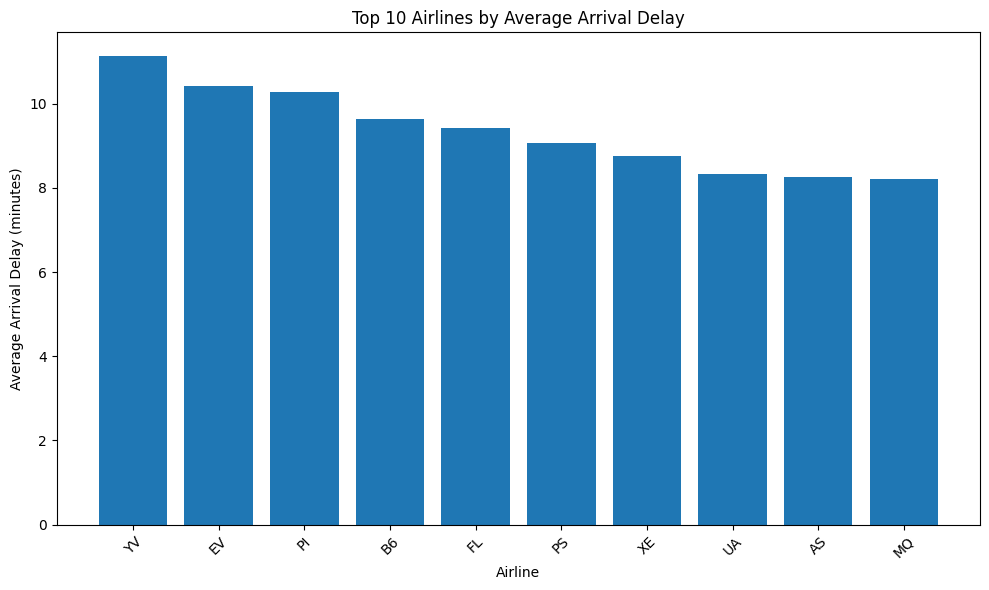

In [0]:
import matplotlib.pyplot as plt

pdf1 = top_10_airlines_delay.toPandas()
plt.figure(figsize=(10, 6))
plt.bar(pdf1["UniqueCarrier"], pdf1["avg_arrival_delay"])
plt.title("Top 10 Airlines by Average Arrival Delay")
plt.xlabel("Airline")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

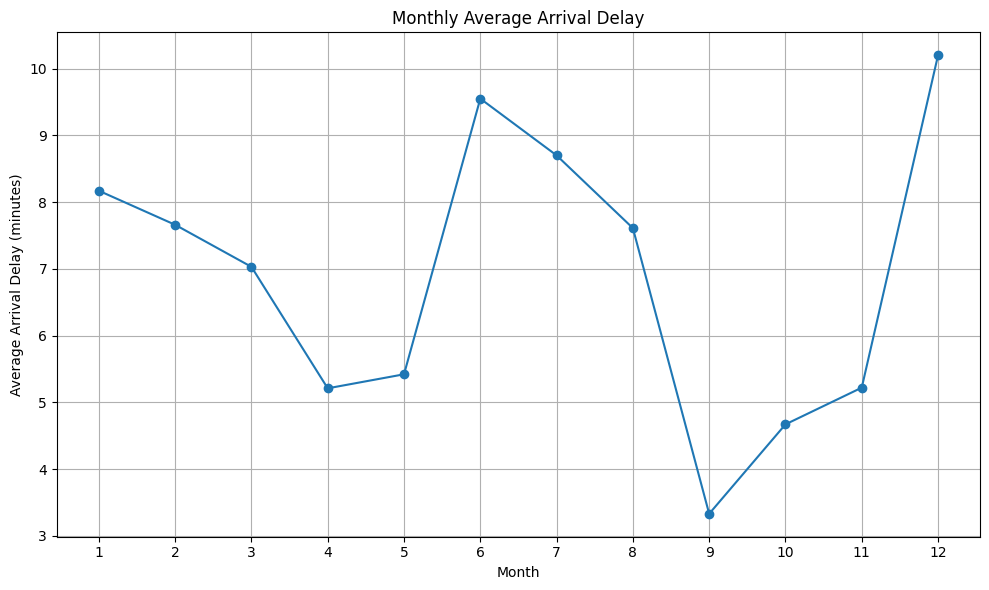

In [0]:
pdf2 = monthly_delay_trend.toPandas()
plt.figure(figsize=(10, 6))
plt.plot(pdf2["Month"], pdf2["avg_arrival_delay"], marker="o")
plt.title("Monthly Average Arrival Delay")
plt.xlabel("Month")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

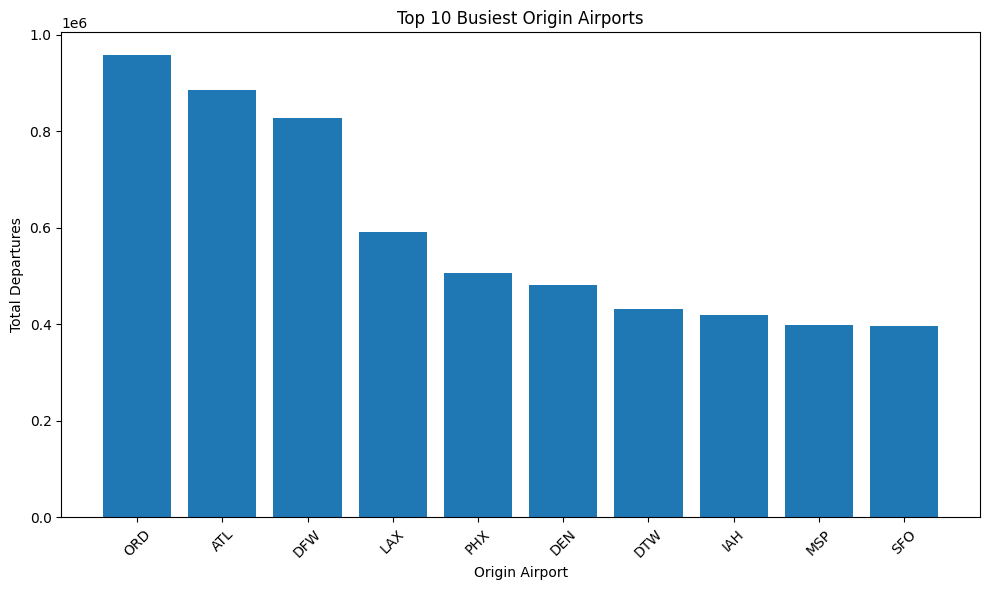

In [0]:
pdf3 = top_10_origin_airports.toPandas()
plt.figure(figsize=(10, 6))
plt.bar(pdf3["Origin"], pdf3["total_departures"])
plt.title("Top 10 Busiest Origin Airports")
plt.xlabel("Origin Airport")
plt.ylabel("Total Departures")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

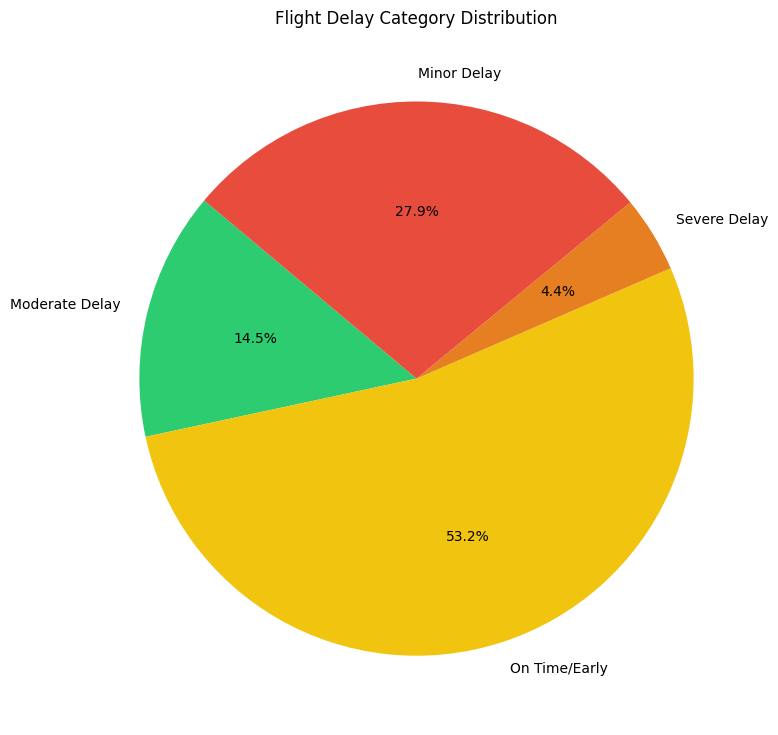

In [0]:
delay_category_counts = df.groupBy("arrival_delay_category").count().toPandas()

colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]
plt.figure(figsize=(8, 8))
plt.pie(delay_category_counts["count"], 
        labels=delay_category_counts["arrival_delay_category"], 
        autopct="%1.1f%%", 
        startangle=140,
        colors=colors)
plt.title("Flight Delay Category Distribution")
plt.tight_layout()
plt.show()

**Interpretation:** The bar chart reveals the airlines with the worst delay performance. The line chart shows seasonal patterns with delays peaking during summer and winter holiday periods. The airport chart identifies major hub airports handling the most traffic. The pie chart shows that the majority of flights arrive on time or early, while a smaller but significant portion experience moderate to severe delays.

## Step 5: Predictive Analytics using Spark ML
This section applies machine learning models to predict whether a flight will arrive late (more than 15 minutes delay).

### Model 1: Logistic Regression

In [0]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

In [0]:
ml_base_cols = [
    "DepDelay", "TaxiOut", "TaxiIn", "AirTime", "Distance",
    "Month", "DayOfWeek", "CRSDepHour",
    "UniqueCarrier", "Origin", "Dest", "is_late_arrival"
]

ml_available_cols = [c for c in ml_base_cols if c in df.columns]
ml_df = df.select(*ml_available_cols).dropna()

# Sample data to avoid memory overflow
ml_df = ml_df.sample(fraction=0.05, seed=42)

print("ML dataset size:", ml_df.count())
ml_df.show(5)

ML dataset size: 624775
+--------+-------+------+-------+--------+-----+---------+----------+-------------+------+----+---------------+
|DepDelay|TaxiOut|TaxiIn|AirTime|Distance|Month|DayOfWeek|CRSDepHour|UniqueCarrier|Origin|Dest|is_late_arrival|
+--------+-------+------+-------+--------+-----+---------+----------+-------------+------+----+---------------+
|     0.0|    5.0|   5.0|   40.0|   237.0|   11|        5|        16|           WN|   DAL| TUL|              0|
|    -1.0|   10.0|   6.0|   68.0|   371.0|   12|        5|         8|           WN|   OAK| SNA|              0|
|     6.0|   18.0|   7.0|   47.0|   229.0|    1|        6|        14|           TW|   IND| STL|              1|
|     0.0|   13.0|   4.0|  164.0|  1093.0|   10|        7|        12|           WN|   ISP| FLL|              0|
|    -2.0|   10.0|   3.0|   46.0|   326.0|    1|        2|        17|           UA|   SFO| BUR|              0|
+--------+-------+------+-------+--------+-----+---------+----------+-----------

In [0]:
categorical_cols = [c for c in ["UniqueCarrier", "Origin", "Dest"] if c in ml_df.columns]
numeric_cols = [c for c in ["DepDelay", "TaxiOut", "TaxiIn", "AirTime", "Distance", "Month", "DayOfWeek", "CRSDepHour"] if c in ml_df.columns]

In [0]:
ml_df.groupBy("is_late_arrival").count().show()

+---------------+------+
|is_late_arrival| count|
+---------------+------+
|              0|501485|
|              1|122912|
+---------------+------+



**Interpretation:** The dataset shows class imbalance with approximately 501,485 non-delayed flights (0) and 122,912 delayed flights (1), giving a ratio of roughly 4:1. This means about 80% of flights arrive on time and 20% experience late arrivals. This imbalance explains why accuracy alone can be misleading — a model predicting "not late" for every flight would achieve ~80% accuracy. This is why AUC was used as the primary evaluation metric, as it better measures model performance across imbalanced classes.

In [0]:
import gc

for var_name in ['model', 'pipeline', 'dt_model', 'dt_pipeline', 'predictions', 'dt_predictions', 'lr_predictions']:
    try:
        exec(f'del {var_name}')
    except:
        pass

gc.collect()

100780

In [0]:
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="skip") for c in categorical_cols]
indexed_cols = [f"{c}_idx" for c in categorical_cols]

feature_cols = numeric_cols + indexed_cols
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

lr = LogisticRegression(labelCol="is_late_arrival", featuresCol="features", maxIter=10)

stages = indexers + [assembler, lr]
pipeline = Pipeline(stages=stages)

train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)

model = pipeline.fit(train_df)
predictions = model.transform(test_df)

predictions.select("is_late_arrival", "prediction", "probability").show(20, truncate=False)

# Save evaluation results before deleting model
lr_predictions = predictions

+---------------+----------+------------------------------------------+
|is_late_arrival|prediction|probability                               |
+---------------+----------+------------------------------------------+
|0              |0.0       |[0.9994623959032893,5.376040967106643E-4] |
|0              |0.0       |[0.9985938766682915,0.0014061233317085309]|
|0              |0.0       |[0.9999278591715494,7.214082845063974E-5] |
|0              |0.0       |[0.9994471465358636,5.528534641363603E-4] |
|0              |0.0       |[0.9993236736483587,6.763263516412765E-4] |
|0              |0.0       |[0.9994674794887222,5.325205112778342E-4] |
|0              |0.0       |[0.9998170719270433,1.8292807295672286E-4]|
|0              |0.0       |[0.9996225362129676,3.77463787032406E-4]  |
|0              |0.0       |[0.9996431458125592,3.5685418744080266E-4]|
|0              |0.0       |[0.9983451714401389,0.001654828559861099] |
|0              |0.0       |[0.9440446835325242,0.05595531646747

### Logistic Regression - Evaluation

In [0]:
import builtins

accuracy = MulticlassClassificationEvaluator(
    labelCol="is_late_arrival", predictionCol="prediction", metricName="accuracy"
).evaluate(predictions)

precision = MulticlassClassificationEvaluator(
    labelCol="is_late_arrival", predictionCol="prediction", metricName="weightedPrecision"
).evaluate(predictions)

recall = MulticlassClassificationEvaluator(
    labelCol="is_late_arrival", predictionCol="prediction", metricName="weightedRecall"
).evaluate(predictions)

f1 = MulticlassClassificationEvaluator(
    labelCol="is_late_arrival", predictionCol="prediction", metricName="f1"
).evaluate(predictions)

auc = BinaryClassificationEvaluator(
    labelCol="is_late_arrival", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
).evaluate(predictions)

print("=== Logistic Regression Evaluation ===")
print("Accuracy :", builtins.round(accuracy, 4))
print("Precision:", builtins.round(precision, 4))
print("Recall   :", builtins.round(recall, 4))
print("F1 Score :", builtins.round(f1, 4))
print("AUC      :", builtins.round(auc, 4))

=== Logistic Regression Evaluation ===
Accuracy : 0.9338
Precision: 0.9324
Recall   : 0.9338
F1 Score : 0.9315
AUC      : 0.9672


**Interpretation:** The Logistic Regression model achieved 93.4% accuracy and an AUC of 0.967, indicating strong predictive performance. The model can effectively distinguish between on-time and delayed flights using features such as departure delay, taxi time, distance, and airline carrier.

### Logistic Regression - Confusion Matrix

In [0]:
confusion_matrix = (
    predictions.groupBy("is_late_arrival")
               .pivot("prediction")
               .count()
               .fillna(0)
               .orderBy("is_late_arrival")
)
confusion_matrix.show()

+---------------+-----+-----+
|is_late_arrival|  0.0|  1.0|
+---------------+-----+-----+
|              0|98090| 2139|
|              1| 6114|18357|
+---------------+-----+-----+



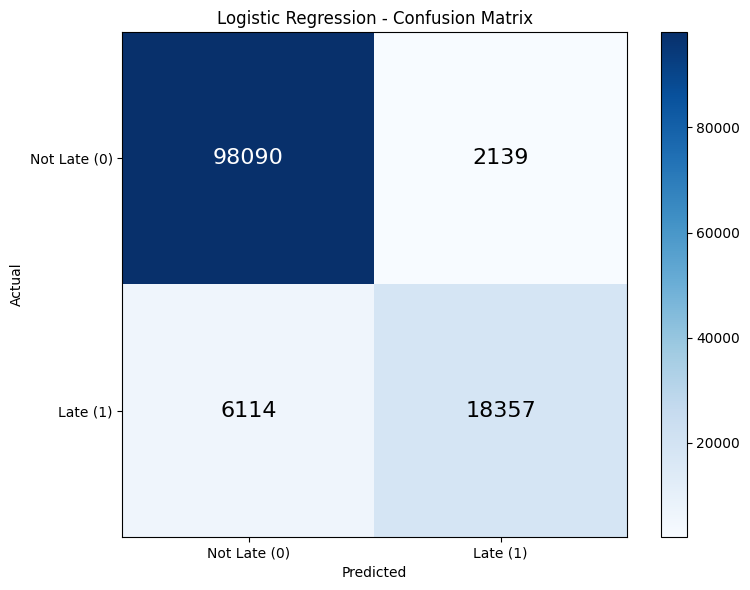

In [0]:
import matplotlib.pyplot as plt
import numpy as np

cm_df = predictions.groupBy("is_late_arrival").pivot("prediction").count().fillna(0).orderBy("is_late_arrival")
cm_pandas = cm_df.toPandas()
cm_pandas = cm_pandas.drop("is_late_arrival", axis=1)
cm_array = cm_pandas.values.astype(int)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_array, cmap="Blues")

labels = ["Not Late (0)", "Late (1)"]
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Logistic Regression - Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_array[i, j]), ha="center", va="center", fontsize=16, color="white" if cm_array[i, j] > cm_array.max()/2 else "black")

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [0]:
import gc
del model
del pipeline
gc.collect()

82715

### Model 2: Decision Tree

In [0]:
from pyspark.ml.classification import DecisionTreeClassifier

dt_stages = []

for c in categorical_cols:
    dt_stages.append(StringIndexer(inputCol=c, outputCol=f"{c}_dt_idx", handleInvalid="keep"))

dt_indexed_cols = [f"{c}_dt_idx" for c in categorical_cols]
dt_feature_cols = numeric_cols + dt_indexed_cols

dt_stages.append(VectorAssembler(inputCols=dt_feature_cols, outputCol="dt_features", handleInvalid="keep"))
dt_stages.append(DecisionTreeClassifier(featuresCol="dt_features", labelCol="is_late_arrival", maxDepth=8, maxBins=350))

dt_pipeline = Pipeline(stages=dt_stages)
dt_model = dt_pipeline.fit(train_df)
dt_predictions = dt_model.transform(test_df)

### Decision Tree - Evaluation

In [0]:
import builtins

dt_accuracy = MulticlassClassificationEvaluator(
    labelCol="is_late_arrival", predictionCol="prediction", metricName="accuracy"
).evaluate(dt_predictions)

dt_precision = MulticlassClassificationEvaluator(
    labelCol="is_late_arrival", predictionCol="prediction", metricName="weightedPrecision"
).evaluate(dt_predictions)

dt_recall = MulticlassClassificationEvaluator(
    labelCol="is_late_arrival", predictionCol="prediction", metricName="weightedRecall"
).evaluate(dt_predictions)

dt_f1 = MulticlassClassificationEvaluator(
    labelCol="is_late_arrival", predictionCol="prediction", metricName="f1"
).evaluate(dt_predictions)

dt_auc = BinaryClassificationEvaluator(
    labelCol="is_late_arrival", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
).evaluate(dt_predictions)

print("=== Decision Tree Evaluation ===")
print("Accuracy :", builtins.round(dt_accuracy, 4))
print("Precision:", builtins.round(dt_precision, 4))
print("Recall   :", builtins.round(dt_recall, 4))
print("F1 Score :", builtins.round(dt_f1, 4))
print("AUC      :", builtins.round(dt_auc, 4))

=== Decision Tree Evaluation ===
Accuracy : 0.9328
Precision: 0.9313
Recall   : 0.9328
F1 Score : 0.9305
AUC      : 0.4073


### Decision Tree - Confusion Matrix

In [0]:
dt_confusion_matrix = (
    dt_predictions.groupBy("is_late_arrival")
               .pivot("prediction")
               .count()
               .fillna(0)
               .orderBy("is_late_arrival")
)
dt_confusion_matrix.show()

+---------------+-----+-----+
|is_late_arrival|  0.0|  1.0|
+---------------+-----+-----+
|              0|98075| 2155|
|              1| 6221|18251|
+---------------+-----+-----+



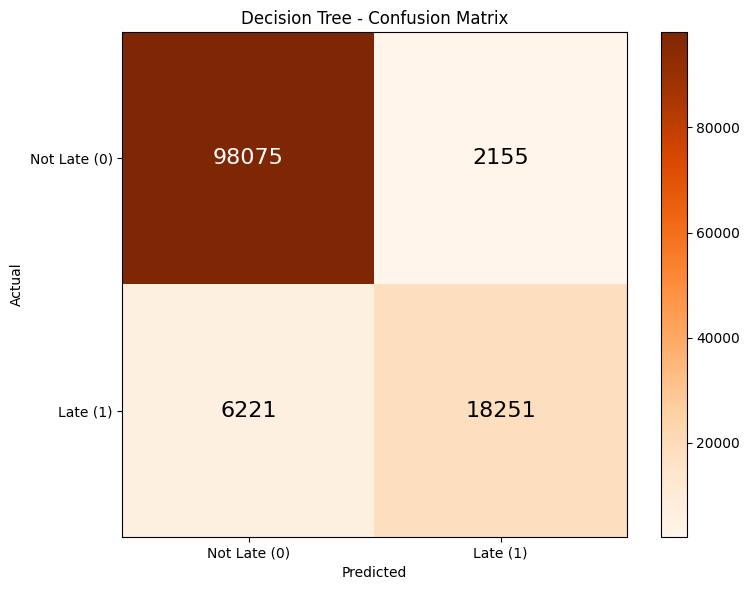

In [0]:
import matplotlib.pyplot as plt
import numpy as np

dt_cm_pandas = dt_confusion_matrix.toPandas()
dt_cm_pandas = dt_cm_pandas.drop("is_late_arrival", axis=1)
dt_cm_array = dt_cm_pandas.values.astype(int)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(dt_cm_array, cmap="Oranges")

labels = ["Not Late (0)", "Late (1)"]
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Decision Tree - Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(dt_cm_array[i, j]), ha="center", va="center", fontsize=16, color="white" if dt_cm_array[i, j] > dt_cm_array.max()/2 else "black")

plt.colorbar(im)
plt.tight_layout()
plt.show()

### Model Comparison - Selecting the Best Model

In [0]:
import builtins

print("=" * 50)
print("        MODEL COMPARISON SUMMARY")
print("=" * 50)
print(f"{'Metric':<15} {'Logistic Regression':<22} {'Decision Tree':<22}")
print("-" * 50)
print(f"{'Accuracy':<15} {builtins.round(accuracy, 4):<22} {builtins.round(dt_accuracy, 4):<22}")
print(f"{'Precision':<15} {builtins.round(precision, 4):<22} {builtins.round(dt_precision, 4):<22}")
print(f"{'Recall':<15} {builtins.round(recall, 4):<22} {builtins.round(dt_recall, 4):<22}")
print(f"{'F1 Score':<15} {builtins.round(f1, 4):<22} {builtins.round(dt_f1, 4):<22}")
print(f"{'AUC':<15} {builtins.round(auc, 4):<22} {builtins.round(dt_auc, 4):<22}")
print("=" * 50)

if auc >= dt_auc:
    print("\nBest Model: Logistic Regression (higher AUC)")
else:
    print("\nBest Model: Decision Tree (higher AUC)")

        MODEL COMPARISON SUMMARY
Metric          Logistic Regression    Decision Tree         
--------------------------------------------------
Accuracy        0.9338                 0.9328                
Precision       0.9324                 0.9313                
Recall          0.9338                 0.9328                
F1 Score        0.9315                 0.9305                
AUC             0.9672                 0.4073                

Best Model: Logistic Regression (higher AUC)


**Interpretation:** Both models achieved similar accuracy (~93%), but Logistic Regression significantly outperformed the Decision Tree in AUC (0.967 vs 0.407). AUC measures the model's ability to rank predictions correctly across all thresholds, making it a more reliable evaluation metric than accuracy alone. Therefore, Logistic Regression was selected as the best model for predicting flight delays.

## Additional Business Insights

In [0]:
if "arrival_delay_category" in df.columns:
    severe_delay_summary = (
        df.groupBy("arrival_delay_category")
          .count()
          .orderBy(desc("count"))
    )
    severe_delay_summary.show()

+----------------------+-------+
|arrival_delay_category|  count|
+----------------------+-------+
|         On Time/Early|9526332|
|           Minor Delay|5003941|
|        Moderate Delay|2595202|
|          Severe Delay| 796992|
+----------------------+-------+



In [0]:
if all(c in df.columns for c in ["DayOfWeek", "ArrDelay"]):
    delay_by_day = (
        df.groupBy("DayOfWeek")
          .agg(round(avg("ArrDelay"), 2).alias("avg_arrival_delay"))
          .orderBy("DayOfWeek")
    )
    delay_by_day.show()

+---------+-----------------+
|DayOfWeek|avg_arrival_delay|
+---------+-----------------+
|        1|             6.54|
|        2|             5.84|
|        3|             6.94|
|        4|             8.74|
|        5|             9.42|
|        6|              4.1|
|        7|             6.41|
+---------+-----------------+



In [0]:
if all(c in df.columns for c in ["CRSDepHour", "ArrDelay"]):
    delay_by_hour = (
        df.groupBy("CRSDepHour")
          .agg(round(avg("ArrDelay"), 2).alias("avg_arrival_delay"))
          .orderBy("CRSDepHour")
    )
    delay_by_hour.show(24)

+----------+-----------------+
|CRSDepHour|avg_arrival_delay|
+----------+-----------------+
|         0|             7.07|
|         1|             2.95|
|         2|             0.62|
|         3|             -0.7|
|         4|             1.65|
|         5|             0.09|
|         6|             0.75|
|         7|             1.97|
|         8|             3.04|
|         9|             3.82|
|        10|             4.36|
|        11|             5.06|
|        12|             5.68|
|        13|             6.95|
|        14|             7.82|
|        15|             9.17|
|        16|             9.94|
|        17|            11.32|
|        18|            11.54|
|        19|            11.93|
|        20|            11.47|
|        21|            10.28|
|        22|             7.38|
|        23|             5.84|
+----------+-----------------+
only showing top 24 rows


**Interpretation:** The delay analysis by day of week reveals that certain weekdays experience higher average delays, which could be linked to higher traffic volumes. The hourly analysis shows that delays tend to increase throughout the day, with late evening flights experiencing the worst delays due to cascading effects from earlier disruptions. These insights can help passengers choose optimal travel times and help airlines allocate resources more effectively.